In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3)

20

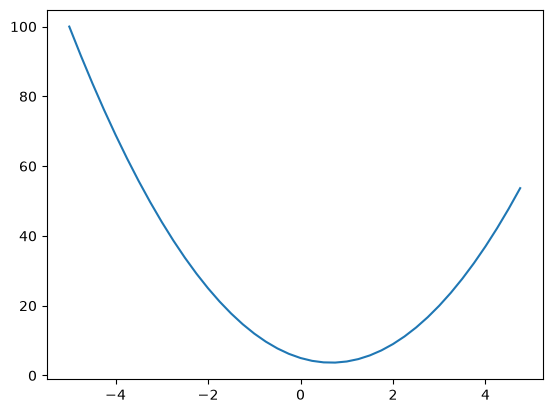

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
# производная
h = 0.00000001
x = 3
(f(x + h) - f(x)) / h

14.00000009255109

In [6]:
a = 2
b = -3
c = 10
d = a * b + c
d

4

In [7]:
h = 0.00001

a = 2
b = -3
c = 10
d1 = a * b + c
c += h
d2 = a * b + c
print(d1)
print(d2)
print('slope ', (d2 - d1) / h)

4
4.00001
slope  0.9999999999621422


In [8]:
from micrograd.engine import Value
from graphviz import Digraph

In [9]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

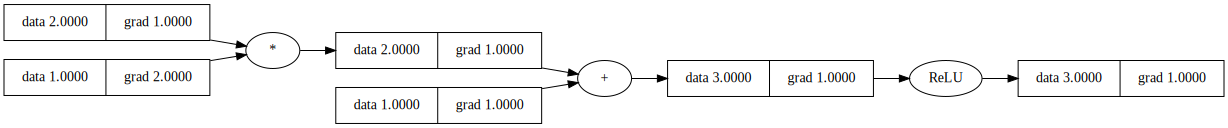

In [10]:
# a very simple example
x = Value(1.0)
y = (x * 2 + 1).relu()
y.backward()
draw_dot(y)

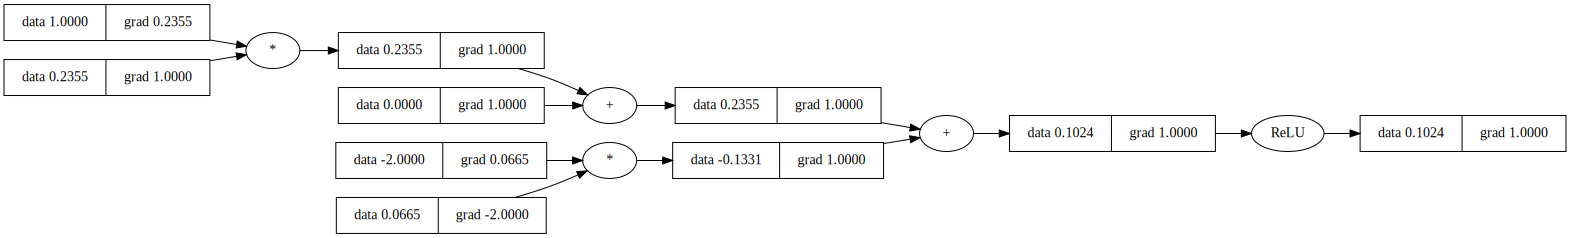

In [11]:
# a simple 2D neuron
import random
from micrograd import nn

random.seed(1337)
n = nn.Neuron(2)
x = [Value(1.0), Value(-2.0)]
y = n(x)
y.backward()

dot = draw_dot(y)
dot

In [12]:
dot.render('gout')

'gout.svg'

In [13]:
from micrograd import nn

In [14]:
x = [2.0, 3.0, -1.0]
n = nn.MLP(3, [4, 4, 1])
n(x)
# draw_dot(n(x))

Value(data=0.17491833012255345, grad=0)

In [16]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [32]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    for p in n.parameters():
        p.data += -0.05 * p.grad
    print(k, loss.data)

0 1.1711850272974045e-05
1 1.1225792049289645e-05
2 1.0830415245135375e-05
3 1.0382270705951582e-05
4 1.0015380827552485e-05
5 9.602145813139094e-06
6 9.26173657626073e-06
7 8.8806500679355e-06
8 8.564851226830974e-06
9 8.213375116672375e-06
10 7.920443851363126e-06
11 7.596244454254813e-06
12 7.3245572293543095e-06
13 7.025488381056332e-06
14 6.7735332598776575e-06
15 6.497620859437977e-06
16 6.263990256161334e-06
17 6.009418124336384e-06
18 5.7928019765768746e-06
19 5.557898913733322e-06


In [33]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9982599750736181, grad=0),
 Value(data=-1.0001813019968686, grad=0),
 Value(data=-1.0001813019968686, grad=0),
 Value(data=0.9984954566523975, grad=0)]